# Solving the default layout instance with `pyomo-cp`

This example comes from a deployed Streamlit plant-layout application, [plant-layout.griffith-pse.com](https://plant-layout.griffith-pse.com/) (part of [griffith-pse.com](https://griffith-pse.com)). The app builds a **`pyomo.gdp`** model (a 4-way non-overlap
disjunction per pair of blocks) and normally solves it by reformulating the
disjunctions to a MILP (big-M) and calling **Gurobi**.

This notebook takes the same `pyomo.gdp` model and solves it with
**CP-SAT** (Google OR-Tools) instead, through the
[`pyomo-cp`](https://github.com/devin-griff/pyomo-cp) package. The disjunctions
map to native reified CP constraints rather than being reformulated, and the
continuous coordinates are placed on a half-unit grid chosen to capture this
instance exactly. The result is the same optimum the app's MILP path finds:
**255.5**.

> Install once: `pip install "pyomo-cp[cpsat]"` (pulls in Pyomo and OR-Tools).

In [1]:
# !pip install "pyomo-cp[cpsat]"
import random
import time

import pyomo.environ as pyo
from pyomo.gdp import Disjunction

import pyomo_cp  # registers the 'cp.discretize' transform and the 'cpsat' solver

## 1. The default instance

The app's default instance is `seed = 1` with 15 objects: a fixed 9x1 pipe
**rack** (object 1) plus 14 small units, each with a length, width, unit pipe
cost, and a north/south rack end it ties into. Two zero-length **tie-in
headers** are appended (indices 16 and 17) as virtual pipe targets pinned to
the rack's ends.

On top of the rack tie-ins, the instance carries direct **unit-to-unit
connections** (close-coupled pairs): a disjoint pairing of the units is rolled
once from an independent seed, and the first 3 pairs are active at pipe cost
10 per unit distance (the app's "Connections" and "Cost x" defaults). This is
exactly the `_gen_objects` / `_gen_pairs` / `_objs_to_inputs` logic from
`app.py`.

In [2]:
RACK_LEN, RACK_WID = 9, 1
DEFAULT_SEED, DEFAULT_N = 1, 15
DEFAULT_PAIRS, PAIR_WEIGHT = 3, 10


def gen_objects(seed, objs):
    """Roll dims/costs/side for non-rack objects; rack stays fixed. Same RNG
    sequence as the app."""
    rng = random.Random(seed)
    objs = list(objs)
    rack = objs[0]
    length, width, cost = {rack: RACK_LEN}, {rack: RACK_WID}, {rack: 0}
    for oid in objs[1:]:
        length[oid] = rng.randint(1, 3)
        width[oid] = rng.randint(1, 3)
        cost[oid] = rng.randint(1, 3)
    side = {oid: rng.choice(["N", "S"]) for oid in objs[1:]}
    return objs, length, width, cost, side


def gen_pairs(seed, objs):
    """Roll a full disjoint pairing of the non-rack objects, seeded
    independently of the dims/costs draw. The app activates the first
    DEFAULT_PAIRS of them at pipe cost PAIR_WEIGHT."""
    rng = random.Random(seed + 10_000_019)
    units = list(objs[1:])
    rng.shuffle(units)
    return [(units[k], units[k + 1]) for k in range(0, len(units) - 1, 2)]


def objs_to_inputs(objs, length, width, cost, side, pairs):
    """Map the object list onto build_model's (n, l0, w0, cmat), appending the
    two zero-length N/S headers and adding the active pair costs."""
    nu = len(objs)
    north, south = nu + 1, nu + 2
    n = nu + 2
    l0 = {p: int(length[objs[p - 1]]) for p in range(1, nu + 1)}
    w0 = {p: int(width[objs[p - 1]]) for p in range(1, nu + 1)}
    l0[north] = l0[south] = 0
    w0[north] = w0[south] = RACK_WID
    cmat = [[0.0] * n for _ in range(n)]
    for p in range(2, nu + 1):
        h = north if side[objs[p - 1]] == "N" else south
        cmat[h - 1][p - 1] = float(cost[objs[p - 1]])
    pos = {oid: k + 1 for k, oid in enumerate(objs)}
    for a, b in pairs:
        pa, pb = pos[a], pos[b]
        cmat[max(pa, pb) - 1][min(pa, pb) - 1] += float(PAIR_WEIGHT)
    return n, l0, w0, cmat


objs, length, width, cost, side = gen_objects(DEFAULT_SEED, list(range(1, DEFAULT_N + 1)))
pairs = gen_pairs(DEFAULT_SEED, objs)[:DEFAULT_PAIRS]
n, l0, w0, cmat = objs_to_inputs(objs, length, width, cost, side, pairs)

print(f"{n} blocks (rack + {DEFAULT_N - 1} units + 2 headers)\n")
print(" obj   L   W  cost  side")
for o in objs:
    print(f"{o:>4}  {length[o]:>2}  {width[o]:>2}  {cost[o]:>4}   {side.get(o, '-')}")
print("\nactive unit-to-unit pairs (cost 10 each):", pairs)

17 blocks (rack + 14 units + 2 headers)

 obj   L   W  cost  side
   1   9   1     0   -
   2   1   3     1   N
   3   2   1     2   S
   4   2   2     3   N
   5   2   1     1   N
   6   2   1     2   S
   7   2   3     1   S
   8   3   2     2   N
   9   3   1     3   S
  10   1   2     1   N
  11   1   1     3   N
  12   3   1     2   S
  13   3   1     2   N
  14   3   1     3   S
  15   1   2     2   S

active unit-to-unit pairs (cost 10 each): [(4, 3), (2, 14), (13, 10)]


## 2. The GDP model

This is the app's `build_model` with its default settings: fixed orientation
(`rotate=False`), horizontal symmetry break (`sym=1`), minimum separation
`d = 1`. Distances are **center-to-center rectilinear** (the process-plant
layout literature convention), defined globally so the disjunction decides
only non-overlap. The objective minimizes the plant bounding box plus
cost-weighted piping: each unit to its assigned rack header, plus the direct
unit-to-unit connections.

Two deliberate deviations from `app.py`, both CP-related:

- `l_f` / `w_f` get finite upper bounds. CP-SAT needs finite bounds; the app
  leaves them unbounded, which is fine for MILP. `UB` bounds them without
  changing the optimum.
- The app adds a degeneracy-breaking cut to the left/right disjuncts so that
  Gurobi's solution pool returns distinct physical layouts rather than
  duplicate encodings of one layout. It is omitted here: pyomo-cp does not
  use a solution pool, so the cut buys nothing.

In [3]:
FOOTPRINT_WEIGHT = 1.0
D_DEFAULT = 1


def build_model(n, l0, w0, cmat, d_uniform=D_DEFAULT, sym=1):
    m = pyo.ConcreteModel()
    m.n = pyo.Set(ordered=True, initialize=pyo.RangeSet(1, n))
    m.p = pyo.Set(initialize=m.n * m.n, dimen=2, filter=lambda m, i, j: i > j)

    m.w0 = pyo.Param(m.n, initialize=w0)
    m.l0 = pyo.Param(m.n, initialize=l0)

    c_dict = {(i, j): float(cmat[i - 1][j - 1]) for i, j in m.p}
    d_dict = {(i, j): float(d_uniform) for i, j in m.p}
    # Headers (zero-length) impose no separation.
    _hdr = {i for i in m.n if l0[i] == 0}
    for (i, j) in d_dict:
        if i in _hdr or j in _hdr:
            d_dict[(i, j)] = 0.0
    m.c = pyo.Param(m.p, initialize=c_dict)
    m.d = pyo.Param(m.p, initialize=d_dict)

    m.UB = pyo.Param(initialize=sum(max(m.l0[i], m.w0[i]) for i in m.n))

    m.x = pyo.Var(m.n, bounds=(0, m.UB))
    m.y = pyo.Var(m.n, bounds=(0, m.UB))
    m.l = pyo.Var(m.n, bounds=(0, m.UB))
    m.w = pyo.Var(m.n, bounds=(0, m.UB))
    m.dx = pyo.Var(m.p, bounds=(0, m.UB))
    m.dy = pyo.Var(m.p, bounds=(0, m.UB))
    # CP-SAT needs finite bounds; the app leaves these unbounded (fine for MILP).
    # UB bounds them without changing the optimum.
    m.l_f = pyo.Var(bounds=(0, m.UB))
    m.w_f = pyo.Var(bounds=(0, m.UB))

    @m.Constraint(m.n)
    def plant_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]

    @m.Constraint(m.n)
    def plant_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    m.rack_at_origin = pyo.Constraint(expr=m.y[1] == 0)
    m.plant_len_eq_rack = pyo.Constraint(expr=m.l_f == m.l[1])

    _headers = sorted(i for i in m.n if l0[i] == 0)
    if len(_headers) >= 1:
        hn = _headers[0]
        m.pin_north_x = pyo.Constraint(expr=m.x[hn] == m.x[1])
        m.pin_north_y = pyo.Constraint(expr=m.y[hn] == m.l_f)
    if len(_headers) >= 2:
        hs = _headers[1]
        m.pin_south_x = pyo.Constraint(expr=m.x[hs] == m.x[1])
        m.pin_south_y = pyo.Constraint(expr=m.y[hs] == 0)

    # Center-to-center rectilinear distances, defined globally (outside the
    # disjunction) so the objective is independent of the chosen relation.
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i, j] >= (m.x[i] + m.w[i] / 2) - (m.x[j] + m.w[j] / 2)

    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i, j] >= (m.x[j] + m.w[j] / 2) - (m.x[i] + m.w[i] / 2)

    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i, j] >= (m.y[i] + m.l[i] / 2) - (m.y[j] + m.l[j] / 2)

    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i, j] >= (m.y[j] + m.l[j] / 2) - (m.y[i] + m.l[i] / 2)

    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1] / 2 <= m.x[2] + m.w[2] / 2

    m.obj = pyo.Objective(
        expr=FOOTPRINT_WEIGHT * (m.l_f + m.w_f)
        + sum(m.c[i, j] * (m.dx[i, j] + m.dy[i, j]) for i, j in m.p),
        sense=pyo.minimize,
    )

    # Non-overlap GDP: 4-way disjunction per pair, one spatial relation each.
    # (No degeneracy cut: see the note above.)
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.w[i] + m.d[i, j] <= m.x[j]],   # i left of j
            [m.x[j] + m.w[j] + m.d[i, j] <= m.x[i]],   # i right of j
            [m.y[i] + m.l[i] + m.d[i, j] <= m.y[j]],   # i below j
            [m.y[j] + m.l[j] + m.d[i, j] <= m.y[i]],   # i above j
        ]

    # Fixed orientation (rotate=False): length/width pinned to defaults.
    @m.Constraint(m.n)
    def fix_l(m, i):
        return m.l[i] == m.l0[i]

    @m.Constraint(m.n)
    def fix_w(m, i):
        return m.w[i] == m.w0[i]

    return m


model = build_model(n, l0, w0, cmat)
print("model built:", n, "blocks,", len(model.p), "pairwise disjunctions")

model built: 17 blocks, 136 pairwise disjunctions


## 3. Solve with `pyomo-cp` (CP-SAT)

Two steps: discretize the continuous coordinates onto a grid
(`cp.discretize`), then solve with the `cpsat` backend. Discretization is an
explicit modelling choice, never automatic.

The step size matters here. Block dimensions are 1 to 3, so with odd
dimensions the center-to-center objective can be optimal with a block at a
half-integer coordinate, and the unit grid would miss that. A **half-unit
grid** (`step = 1/2`) contains those points: on this instance it recovers the
app's continuous optimum exactly.

CP-SAT proves the optimum in about a minute on a laptop.

In [4]:
pyo.TransformationFactory("cp.discretize").apply_to(model, step=1 / 2)  # explicit; half-unit grid

t0 = time.perf_counter()
res = pyo.SolverFactory("cpsat").solve(model, workers=8, seed=42, time_limit=600, tee=True)
wall = time.perf_counter() - t0

print("termination:", res.solver.termination_condition)
print("objective  :", pyo.value(model.obj))
print(f"wall time  : {wall:.1f} s")

Starting CP-SAT solver v9.15.6755


Parameters: random_seed: 42 max_time_in_seconds: 600 log_search_progress: true num_search_workers: 8 log_to_stdout: false


Initial optimization model '': (model_fingerprint: 0x38cb5245900ce0fc)
#Variables: 886 (#ints: 36 in objective) (709 primary variables)
  - 544 Booleans in [0,1]
  - 342 in [0,90]
#kExactlyOne: 136 (#literals: 544)
#kLinear1: 36
#kLinear2: 4
#kLinear3: 578 (#enforced: 544)
#kLinearN: 545 (#terms: 2'724)


Starting presolve at 0.04s


  1.61e-03s  0.00e+00d  [DetectDominanceRelations] 


...

Improving bounds shared    Num  Sym
                  'core':   59    0
            'default_lp':   21    0
                 'no_lp':    5    0
         'quick_restart':  222    0
         'reduced_costs':   93    0



Clauses shared        #Exported  #Imported  #BinaryRead  #BinaryTotal
             'core':        102        455          127           128
       'default_lp':        148        369          127           128
  'fs_random_no_lp':          0          0            0           128
           'max_lp':         40        483          127           128
            'no_lp':        189        348          127           128
    'quick_restart':        212        329          128           128
    'reduced_costs':         12        405          125           128



LRAT_status: NA


CpSolverResponse summary:
status: OPTIMAL
objective: 511
best_bound: 511
integers: 51
booleans: 404
conflicts: 16
branches: 982
propagations: 2218
integer_propagations: 1338
restarts: 0
lp_iterations: 0
walltime: 47.4402
usertime: 47.4402
deterministic_time: 100.847
gap_integral: 28
solution_fingerprint: 0x9bba9c4beedf5260



termination: optimal
objective  : 255.5
wall time  : 50.9 s


## 4. The layout

Read the block placements back off the Pyomo variables (`pyomo-cp` loads the
CP-SAT solution onto them) and draw the same picture the app renders: the rack
spanning the plant length, units placed left and right, headers flush to the
rack ends.

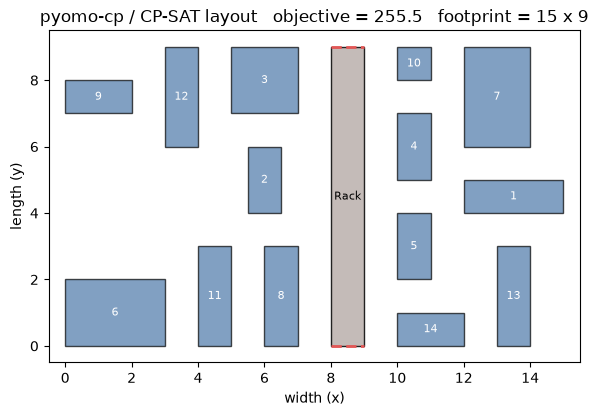

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 6))
for i in model.n:
    xi, yi = pyo.value(model.x[i]), pyo.value(model.y[i])
    wi, li = pyo.value(model.w[i]), pyo.value(model.l[i])
    is_rack = (i == 1)
    is_header = (l0[i] == 0)
    if is_header:
        ax.plot([xi, xi + max(wi, RACK_WID)], [yi, yi], color="#E45756",
                lw=2, ls="--", zorder=3)
        continue
    ax.add_patch(Rectangle((xi, yi), wi, li,
                           facecolor="#BAB0AC" if is_rack else "#4C78A8",
                           edgecolor="black", alpha=0.85 if is_rack else 0.7))
    ax.text(xi + wi / 2, yi + li / 2, "Rack" if is_rack else str(i - 1),
            ha="center", va="center", fontsize=8,
            color="white" if not is_rack else "black")

Lf, Wf = pyo.value(model.l_f), pyo.value(model.w_f)
ax.set_xlim(-0.5, Wf + 0.5)
ax.set_ylim(-0.5, Lf + 0.5)
ax.set_aspect("equal")
ax.set_title(f"pyomo-cp / CP-SAT layout   "
             f"objective = {pyo.value(model.obj):g}   "
             f"footprint = {Wf:g} x {Lf:g}")
ax.set_xlabel("width (x)")
ax.set_ylabel("length (y)")
plt.tight_layout()
plt.show()

The same `pyomo.gdp` model the app reformulates to a MILP for Gurobi is solved
here by CP-SAT through `pyomo-cp` and returns the same optimum (**255.5**).
The only CP-specific steps are the explicit `cp.discretize` call (half-unit
grid, exact for this instance) and finite bounds on the two plant-extent
variables; the model is otherwise identical.